# Functional Cluster Analysis

In biological neural networks, neurons organize into functional clusters — groups that process related information. Identifying and measuring these clusters is critical for understanding network function.

This notebook covers methods for:
1. **Detecting clusters** — finding groups of densely-connected nodes
2. **Measuring cluster quality** — quantifying how well-defined clusters are
3. **Comparing networks** — evaluating different generative methods by their cluster structure

We will generate networks using methods from previous notebooks and analyze their modular organization using both classical graph clustering techniques and biologically-motivated metrics.

In [1]:
# Install required packages
!pip install python-louvain scikit-learn -q

In [31]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
from scipy.sparse.linalg import eigsh
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from community import community_louvain # Corrected import for python-louvain
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
np.random.seed(42)

print("All imports successful!")

All imports successful!


## What is a "Functional Cluster"?

A **functional cluster** is a group of nodes that are more densely connected to each other than to the rest of the network.

**In the brain:** The visual cortex, motor cortex, and prefrontal cortex are each functional modules. Neurons within a module communicate intensively; communication between modules is sparse but targeted.

**In our generated networks:** Clusters emerge naturally from the spatial and pruning-based generation processes. Networks generated with biological constraints should show stronger clustering than random models.

**Distinction:**
- **Structural clusters:** Based on connectivity patterns (whether edges exist)
- **Functional clusters:** Based on shared activity patterns or information processing roles

In this notebook, we focus on **structural clusters** as proxies for functional organization, since they can be measured directly from network topology.

## Section 1: Generating Test Networks

We generate several types of networks for comparison: random Erdős-Rényi, small-world, scale-free, and our biologically-inspired model.

In [26]:
# Helper functions from previous notebooks

def generate_inverse_square_graph(n=80, seed=42):
    """
    Generate spatially embedded graph with inverse-square distance weights.
    Nodes placed randomly in 2D space; edge weight = 1/distance^2.
    """
    np.random.seed(seed)
    positions = np.random.rand(n, 2) * 10  # 10x10 area

    G = nx.Graph()
    G.add_nodes_from(range(n))

    # Connect all pairs with inverse-square weights
    for i in range(n):
        for j in range(i+1, n):
            dist = np.linalg.norm(positions[i] - positions[j])
            if dist > 0:
                weight = 1.0 / (dist ** 2)
                G.add_edge(i, j, weight=weight, distance=dist)

    # Store positions as node attributes
    for i in range(n):
        G.nodes[i]['pos'] = positions[i]

    return G


def developmental_pruning(G, n_cycles=4, seed=42):
    """
    Apply multiple pruning cycles to produce a biologically-inspired sparse network.
    Simulates activity-dependent development: weak connections are pruned.
    """
    np.random.seed(seed)
    G_pruned = G.copy()

    for cycle in range(n_cycles):
        # Sort edges by weight
        edges_by_weight = sorted(G_pruned.edges(data=True),
                                 key=lambda x: x[2]['weight'])

        # Remove weakest edges (bottom 30% each cycle)
        n_remove = max(1, int(0.30 * len(edges_by_weight)))
        edges_to_remove = edges_by_weight[:n_remove]

        for u, v, _ in edges_to_remove:
            if G_pruned.has_edge(u, v):
                G_pruned.remove_edge(u, v)

    return G_pruned


print("Helper functions defined.")

Helper functions defined.


In [27]:
# Generate comparison networks
n = 80
np.random.seed(42)

# Standard random graph models
G_er = nx.erdos_renyi_graph(n, 0.1, seed=42)
G_ws = nx.newman_watts_strogatz_graph(n, 4, 0.1, seed=42)
G_ba = nx.barabasi_albert_graph(n, 3, seed=42)

# Biologically-inspired graph
G_bio = developmental_pruning(generate_inverse_square_graph(n, seed=42), n_cycles=4, seed=42)

# Add random weights to unweighted graphs for fair comparison
for G in [G_er, G_ws, G_ba]:
    for u, v in G.edges():
        G[u][v]['weight'] = np.random.lognormal(0, 0.5)

# Ensure bio network has normalized weights
max_weight = max(d['weight'] for u, v, d in G_bio.edges(data=True))
for u, v in G_bio.edges():
    G_bio[u][v]['weight'] = G_bio[u][v]['weight'] / max_weight

networks = {
    "Erdős-Rényi": G_er,
    "Newman-Watts-Strogatz": G_ws,
    "Barabási-Albert": G_ba,
    "Bio-inspired (pruned)": G_bio
}

# Print basic statistics
for name, G in networks.items():
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)
    avg_degree = 2 * n_edges / n_nodes
    print(f"{name:30s} | Nodes: {n_nodes:3d}, Edges: {n_edges:4d}, Density: {density:.3f}, Avg Degree: {avg_degree:.2f}")

Erdős-Rényi                    | Nodes:  80, Edges:  307, Density: 0.097, Avg Degree: 7.67
Newman-Watts-Strogatz          | Nodes:  80, Edges:  174, Density: 0.055, Avg Degree: 4.35
Barabási-Albert                | Nodes:  80, Edges:  231, Density: 0.073, Avg Degree: 5.78
Bio-inspired (pruned)          | Nodes:  80, Edges:  760, Density: 0.241, Avg Degree: 19.00


## Section 2: Non-Weighted Clustering Methods

We start with classical clustering methods that ignore edge weights.

### 2.1 Connected Components

The simplest form of "clustering" is identifying disconnected subgraphs. Nodes in the same component can reach each other; different components cannot.

This is rarely useful for analyzing fully connected networks, but it serves as a baseline.

In [28]:
# Analyze connected components
print("Connected Components Analysis:")
print("="*60)
for name, G in networks.items():
    n_components = nx.number_connected_components(G)
    components = list(nx.connected_components(G))
    component_sizes = sorted([len(c) for c in components], reverse=True)
    print(f"{name:30s} | # Components: {n_components:3d}, Largest: {component_sizes[0]:3d}, Smallest: {component_sizes[-1]:3d}")

Connected Components Analysis:
Erdős-Rényi                    | # Components:   1, Largest:  80, Smallest:  80
Newman-Watts-Strogatz          | # Components:   1, Largest:  80, Smallest:  80
Barabási-Albert                | # Components:   1, Largest:  80, Smallest:  80
Bio-inspired (pruned)          | # Components:   1, Largest:  80, Smallest:  80


### 2.2 Spectral Clustering

Spectral clustering uses eigenvalues of the graph Laplacian matrix. The eigenvectors corresponding to the smallest eigenvalues reveal natural clusters in the graph.

**Key insight:** The Fiedler vector (second-smallest eigenvalue) naturally bisects the graph into two communities.

In [6]:
def spectral_clustering(G, k=4):
    """
    Perform spectral clustering on graph G into k clusters.
    Uses the normalized Laplacian eigendecomposition.
    """
    L = nx.normalized_laplacian_matrix(G, weight=None).toarray()
    eigenvalues, eigenvectors = np.linalg.eigh(L)
    # Use first k eigenvectors (smallest eigenvalues)
    features = eigenvectors[:, :k]
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features)
    return dict(zip(G.nodes(), labels))

# Apply spectral clustering to all networks
spectral_partitions = {}
for name, G in networks.items():
    spectral_partitions[name] = spectral_clustering(G, k=4)

print("Spectral clustering completed for all networks (k=4 clusters).")

Spectral clustering completed for all networks (k=4 clusters).


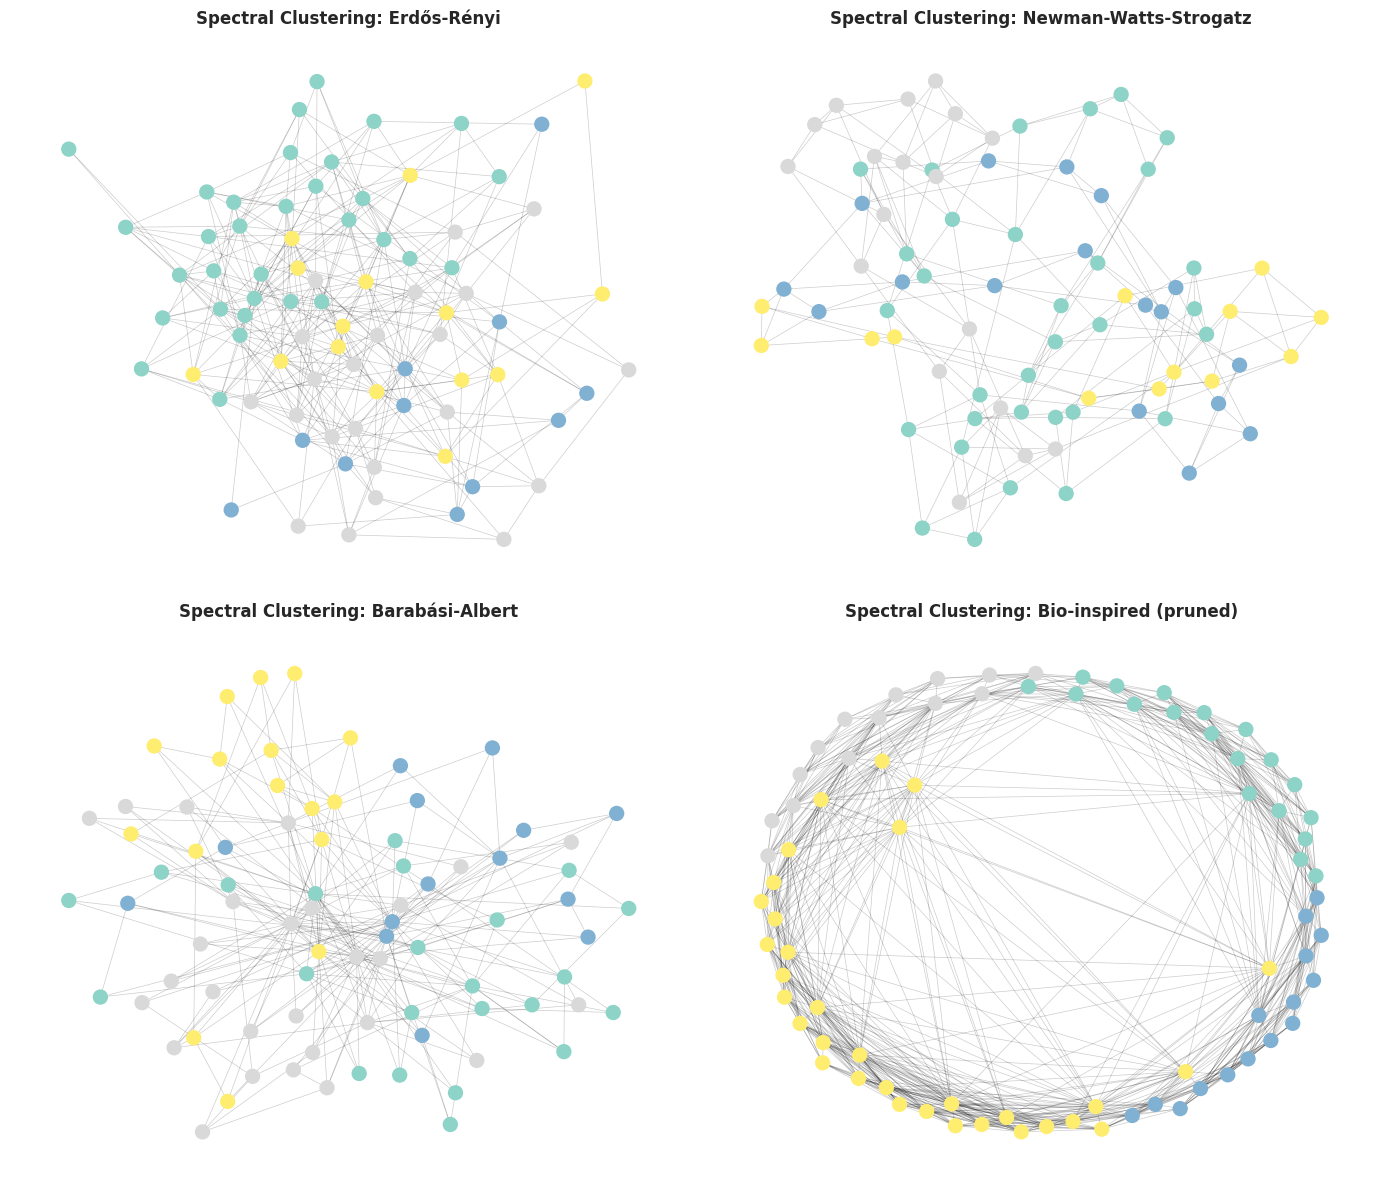

Spectral clustering visualization saved.


In [7]:
# Visualize spectral clustering results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, G) in enumerate(networks.items()):
    ax = axes[idx]
    partition = spectral_partitions[name]

    # Get positions using spring layout
    pos = nx.spring_layout(G, seed=42, k=0.5, iterations=50)

    # Color nodes by cluster
    colors = [partition[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=100,
                          cmap=plt.cm.Set3, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax, width=0.5)

    ax.set_title(f"Spectral Clustering: {name}", fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('spectral_clustering.png', dpi=100, bbox_inches='tight')
plt.show()
print("Spectral clustering visualization saved.")

### 2.3 Louvain Community Detection

The Louvain method uses greedy optimization of Newman's modularity Q. It does not require pre-specifying the number of clusters and is widely used in neuroscience for brain network analysis.

In [30]:
def louvain_clustering(G, seed=42):
    """
    Detect communities using the Louvain method (python-louvain).
    Optimizes Newman's modularity Q.
    """
    # The library uses random number generator internally
    partition = community_louvain.best_partition(G, weight='weight', random_state=seed) # Use community_louvain.best_partition
    return partition

# Apply Louvain to all networks
louvain_partitions = {}
for name, G in networks.items():
    louvain_partitions[name] = louvain_clustering(G, seed=42)
    n_communities = max(louvain_partitions[name].values()) + 1
    print(f"{name:30s} | # Communities detected: {n_communities}")

Erdős-Rényi                    | # Communities detected: 6
Newman-Watts-Strogatz          | # Communities detected: 8
Barabási-Albert                | # Communities detected: 8
Bio-inspired (pruned)          | # Communities detected: 7


In [ ]:
# Visualize Louvain communities
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, G) in enumerate(networks.items()):
    ax = axes[idx]
    partition = louvain_partitions[name]

    # Get positions
    pos = nx.spring_layout(G, seed=42, k=0.5, iterations=50)

    # Color by community
    colors = [partition[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=100,
                          cmap=plt.cm.tab20, ax=ax)
    nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax, width=0.5)

    n_comm = max(colors) + 1
    ax.set_title(f"Louvain Clustering: {name} ({n_comm} communities)", fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('louvain_clustering.png', dpi=100, bbox_inches='tight')
plt.show()
print("Louvain clustering visualization saved.")

### 2.4 Label Propagation

Label propagation is a simple iterative algorithm: each node adopts the label most common among its neighbors. It's fast, requires no parameters, but is non-deterministic.

In [40]:
def label_propagation_clustering(G, max_iters=10, seed=42):
    """
    Perform label propagation clustering.
    Each node iteratively adopts the most common label among its neighbors.
    """
    np.random.seed(seed)
    labels = {node: node for node in G.nodes()}  # Initialize: each node has unique label

    for iteration in range(max_iters):
        new_labels = {}
        for node in G.nodes():
            neighbor_labels = [labels[nbr] for nbr in G.neighbors(node)]
            if neighbor_labels:
                # Most common neighbor label (ties broken randomly)
                label_counts = Counter(neighbor_labels)
                max_count = max(label_counts.values())
                candidates = [l for l, c in label_counts.items() if c == max_count]
                new_labels[node] = np.random.choice(candidates)
            else:
                new_labels[node] = labels[node]
        labels = new_labels

    # Relabel to consecutive integers
    unique_labels = sorted(set(labels.values()))
    label_map = {old: new for new, old in enumerate(unique_labels)}
    return {node: label_map[labels[node]] for node in G.nodes()}

# Apply label propagation
lp_partitions = {}
for name, G in networks.items():
    lp_partitions[name] = label_propagation_clustering(G, max_iters=10, seed=42)
    n_communities = max(lp_partitions[name].values()) + 1
    print(f"{name:30s} | # Communities (label propagation): {n_communities}")

Erdős-Rényi                    | # Communities (label propagation): 1
Newman-Watts-Strogatz          | # Communities (label propagation): 13
Barabási-Albert                | # Communities (label propagation): 3
Bio-inspired (pruned)          | # Communities (label propagation): 3


## Section 3: Weighted Clustering Methods

Real biological networks have varying connection strengths. Weighted methods account for this.

### 3.1 Weighted Modularity

Standard modularity Q only considers whether edges exist. Weighted modularity accounts for edge weights:

$$Q = \frac{1}{2m} \sum_{ij} \left[ w_{ij} - \frac{s_i s_j}{2m} \right] \delta(c_i, c_j)$$

where $s_i$ is the strength (weighted degree) of node $i$.

In [41]:
def weighted_modularity(G, partition):
    """
    Calculate Newman's modularity Q for a weighted graph.
    Q = (1/2m) * sum_ij [ w_ij - (s_i * s_j)/(2m) ] * delta(c_i, c_j)
    where s_i is the weighted degree (strength) of node i.
    """
    # Handle graphs with weights
    m = 0  # Total weight
    for u, v, d in G.edges(data=True):
        weight = d.get('weight', 1)
        m += weight

    if m == 0:
        return 0

    Q = 0
    for u in G.nodes():
        for v in G.nodes():
            if partition[u] == partition[v]:
                # Weight of edge u-v
                w_uv = G[u][v].get('weight', 0) if G.has_edge(u, v) else 0

                # Strength (weighted degree) of u and v
                s_u = sum(G[u][nbr].get('weight', 1) for nbr in G.neighbors(u))
                s_v = sum(G[v][nbr].get('weight', 1) for nbr in G.neighbors(v))

                Q += w_uv - (s_u * s_v) / (2 * m)

    return Q / (2 * m)

# Calculate weighted modularity for all partitions
print("Weighted Modularity Comparison:")
print("="*80)
print(f"{'Network':<30s} | {'Spectral':<10s} | {'Louvain':<10s} | {'Label Prop':<10s}")
print("-"*80)

for name in networks.keys():
    q_spectral = weighted_modularity(networks[name], spectral_partitions[name])
    q_louvain = weighted_modularity(networks[name], louvain_partitions[name])
    q_lp = weighted_modularity(networks[name], lp_partitions[name])
    print(f"{name:<30s} | {q_spectral:<10.4f} | {q_louvain:<10.4f} | {q_lp:<10.4f}")

Weighted Modularity Comparison:
Network                        | Spectral   | Louvain    | Label Prop
--------------------------------------------------------------------------------
Erdős-Rényi                    | 0.2754     | 0.3753     | -0.0000   
Newman-Watts-Strogatz          | 0.5789     | 0.7117     | 0.4971    
Barabási-Albert                | 0.3220     | 0.4087     | -0.0002   
Bio-inspired (pruned)          | 0.5561     | 0.7253     | 0.5030    


In [ ]:
# Compare weighted vs unweighted modularity for Louvain
def unweighted_modularity(G, partition):
    """
    Calculate modularity without considering edge weights.
    """
    m = G.number_of_edges()
    if m == 0:
        return 0

    Q = 0
    for u in G.nodes():
        for v in G.nodes():
            if partition[u] == partition[v]:
                # Just count edges, ignore weights
                a_uv = 1 if G.has_edge(u, v) else 0
                k_u = G.degree(u)
                k_v = G.degree(v)
                Q += a_uv - (k_u * k_v) / (2 * m)

    return Q / (2 * m)

print("\nWeighted vs Unweighted Modularity (Louvain):")
print("="*60)
print(f"{'Network':<30s} | {'Unweighted':<15s} | {'Weighted':<15s}")
print("-"*60)

for name in networks.keys():
    q_unweighted = unweighted_modularity(networks[name], louvain_partitions[name])
    q_weighted = weighted_modularity(networks[name], louvain_partitions[name])
    print(f"{name:<30s} | {q_unweighted:<15.4f} | {q_weighted:<15.4f}")

### 3.2 Weighted Louvain

The Louvain method naturally extends to weighted graphs. It optimizes weighted modularity as the objective function.

In [32]:
def weighted_louvain_clustering(G, seed=42):
    """
    Louvain method applied with edge weights.
    The algorithm uses weights if present in the graph.
    """
    partition = community_louvain.best_partition(G, weight='weight', random_state=seed) # Use community_louvain.best_partition
    return partition

# For our networks, we already used weighted Louvain above
print("Weighted Louvain has already been applied (the previous Louvain results use weights).")
print()
print("Community structure summary:")
for name in networks.keys():
    partition = louvain_partitions[name]
    n_comm = max(partition.values()) + 1
    community_sizes = Counter(partition.values())
    avg_size = np.mean(list(community_sizes.values()))
    print(f"{name:<30s} | Communities: {n_comm:2d}, Avg size: {avg_size:5.1f}")

Weighted Louvain has already been applied (the previous Louvain results use weights).

Community structure summary:
Erdős-Rényi                    | Communities:  6, Avg size:  13.3
Newman-Watts-Strogatz          | Communities:  8, Avg size:  10.0
Barabási-Albert                | Communities:  8, Avg size:  10.0
Bio-inspired (pruned)          | Communities:  7, Avg size:  11.4


### 3.3 Weighted Clustering Coefficient

The weighted clustering coefficient measures how strongly connected triangles are in a network. High values indicate dense, tightly-connected local groups.

In [33]:
def weighted_clustering_coefficient(G):
    """
    Calculate the weighted clustering coefficient for each node.
    For a node with weighted neighbors, this measures the strength of
    clustering relative to the node's strength.
    """
    cc = {}
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        if len(neighbors) < 2:
            cc[node] = 0
            continue

        # Sum of weights in triangles with this node
        triangles_weight = 0
        # Maximum possible weight
        max_weight = 0

        for i, u in enumerate(neighbors):
            w_nu = G[node][u].get('weight', 1)
            max_weight += w_nu

            for v in neighbors[i+1:]:
                w_nv = G[node][v].get('weight', 1)
                w_uv = G[u][v].get('weight', 0) if G.has_edge(u, v) else 0
                triangles_weight += w_uv
                max_weight += w_nv

        if max_weight > 0:
            cc[node] = triangles_weight / max_weight
        else:
            cc[node] = 0

    return cc

print("Weighted Clustering Coefficient Analysis:")
print("="*70)
print(f"{'Network':<30s} | {'Mean':<10s} | {'Std':<10s} | {'Max':<10s}")
print("-"*70)

wcc_results = {}
for name, G in networks.items():
    wcc = weighted_clustering_coefficient(G)
    values = list(wcc.values())
    wcc_results[name] = values
    print(f"{name:<30s} | {np.mean(values):<10.4f} | {np.std(values):<10.4f} | {np.max(values):<10.4f}")

Weighted Clustering Coefficient Analysis:
Network                        | Mean       | Std        | Max       
----------------------------------------------------------------------
Erdős-Rényi                    | 0.0752     | 0.0583     | 0.2757    
Newman-Watts-Strogatz          | 0.2778     | 0.1171     | 0.7539    
Barabási-Albert                | 0.1033     | 0.1029     | 0.4961    
Bio-inspired (pruned)          | 2.0189     | 1.7513     | 7.6311    


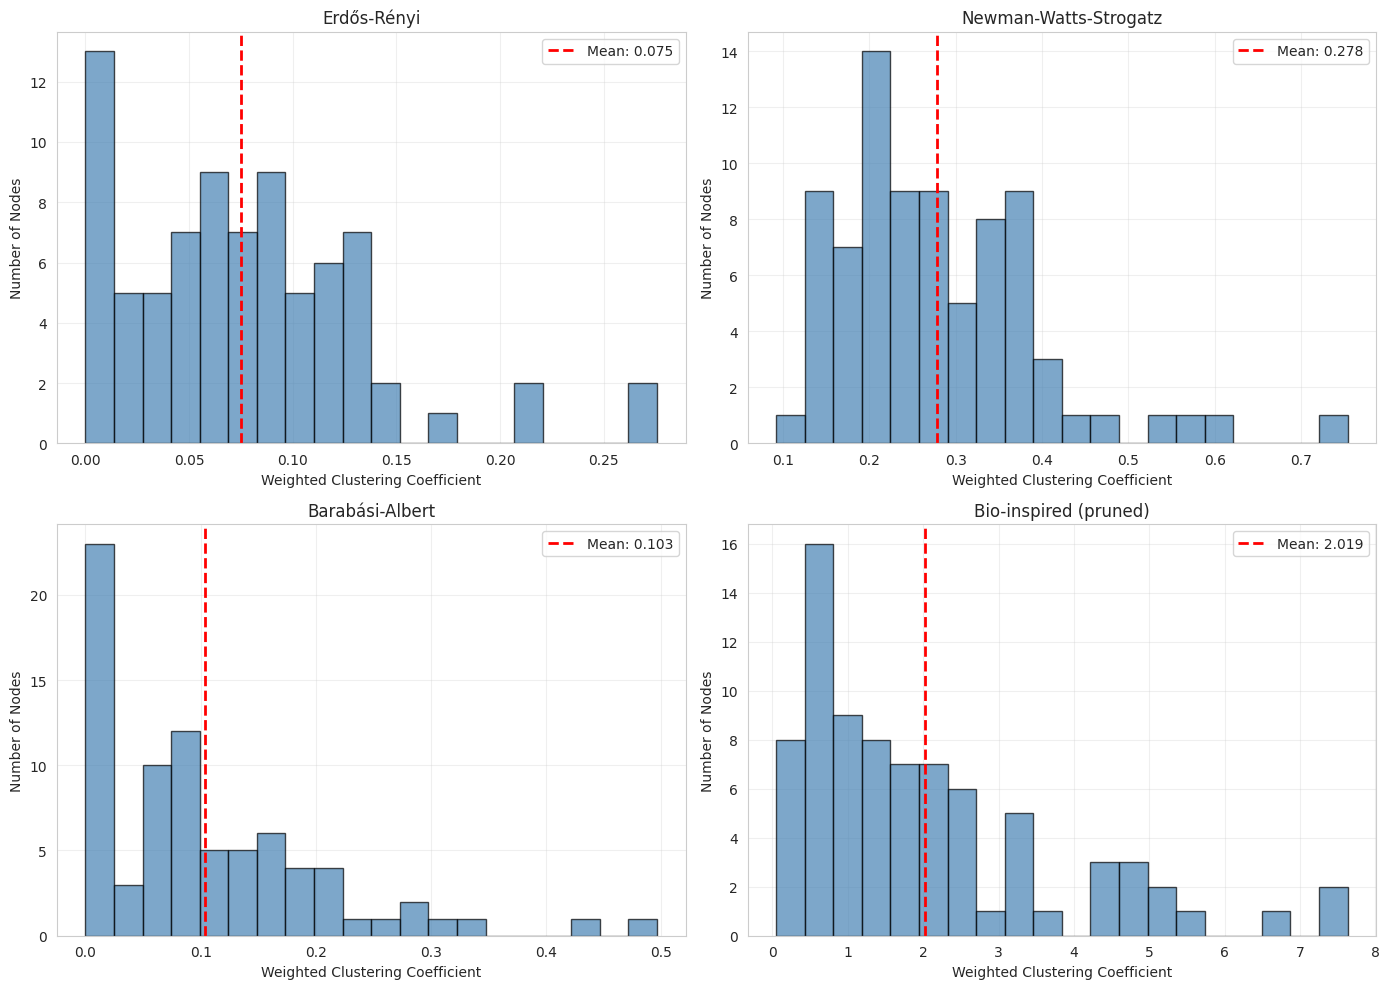

Weighted clustering coefficient distribution saved.


In [34]:
# Visualize weighted clustering coefficient distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, values) in enumerate(wcc_results.items()):
    ax = axes[idx]
    ax.hist(values, bins=20, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(np.mean(values), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(values):.3f}')
    ax.set_xlabel('Weighted Clustering Coefficient')
    ax.set_ylabel('Number of Nodes')
    ax.set_title(f"{name}")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('weighted_clustering_coefficient.png', dpi=100, bbox_inches='tight')
plt.show()
print("Weighted clustering coefficient distribution saved.")

## Section 4: Hierarchical Clustering

Hierarchical clustering reveals multi-scale organization. We can analyze clusters at different levels of the hierarchy.

### 4.1 Agglomerative Hierarchical Clustering

Start with each node as its own cluster and iteratively merge the most similar clusters.

In [35]:
def hierarchical_clustering(G, method='ward', n_clusters=4):
    """
    Hierarchical clustering based on shortest path distances.
    Returns: partition dict and linkage matrix Z.
    """
    # Compute shortest path distances
    path_lengths = dict(nx.shortest_path_length(G))
    n = len(G.nodes())
    nodes = list(G.nodes())

    # Build distance matrix
    dist_matrix = np.zeros((n, n))
    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            if u in path_lengths and v in path_lengths[u]:
                dist_matrix[i][j] = path_lengths[u][v]
            else:
                dist_matrix[i][j] = n + 1  # Disconnected nodes

    # Convert to condensed distance matrix
    condensed = squareform(dist_matrix)

    # Perform hierarchical clustering
    Z = linkage(condensed, method=method)

    # Cut dendrogram at desired number of clusters
    labels = fcluster(Z, t=n_clusters, criterion='maxclust')

    return dict(zip(nodes, labels - 1)), Z  # -1 to start from 0

# Apply hierarchical clustering
hierarchical_partitions = {}
hierarchical_linkages = {}
for name, G in networks.items():
    partition, Z = hierarchical_clustering(G, method='ward', n_clusters=4)
    hierarchical_partitions[name] = partition
    hierarchical_linkages[name] = Z

print("Hierarchical clustering completed for all networks.")

Hierarchical clustering completed for all networks.


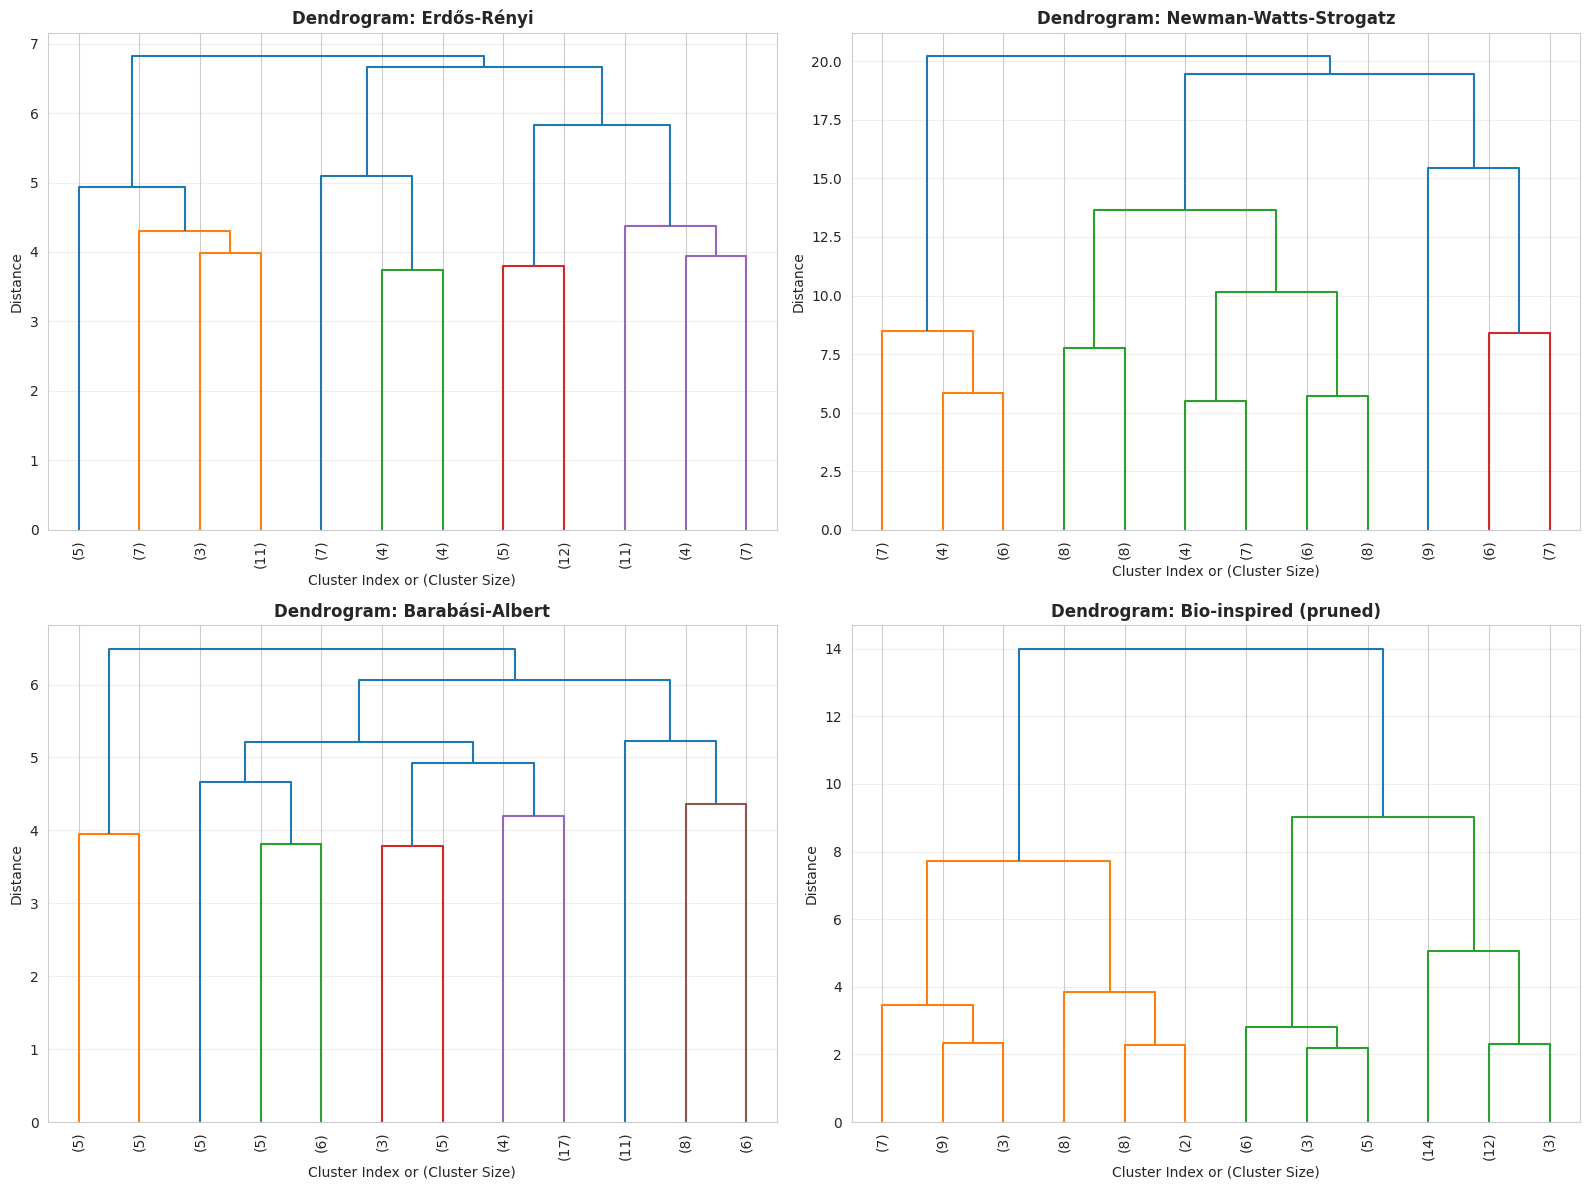

Dendrograms saved.


In [36]:
# Visualize dendrograms
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, Z) in enumerate(hierarchical_linkages.items()):
    ax = axes[idx]
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=12,
               leaf_rotation=90, leaf_font_size=10)
    ax.set_title(f"Dendrogram: {name}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Cluster Index or (Cluster Size)')
    ax.set_ylabel('Distance')
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dendrograms.png', dpi=100, bbox_inches='tight')
plt.show()
print("Dendrograms saved.")

### 4.2 Hierarchical Modularity

By cutting the dendrogram at different levels, we can measure modularity as a function of the number of clusters. This reveals the "natural" number of communities.

In [42]:
def modularity_vs_clusters(G, Z, max_clusters=20):
    """
    Calculate modularity for different numbers of clusters.
    """
    n_nodes = len(G.nodes())
    max_clusters = min(max_clusters, n_nodes - 1)

    cluster_counts = []
    modularities = []

    for n_clusters in range(2, max_clusters + 1):
        labels = fcluster(Z, t=n_clusters, criterion='maxclust')
        partition = dict(zip(G.nodes(), labels - 1))
        q = weighted_modularity(G, partition)
        cluster_counts.append(n_clusters)
        modularities.append(q)

    return cluster_counts, modularities

print("Computing modularity curves...")
modularity_curves = {}
for name, G in networks.items():
    Z = hierarchical_linkages[name]
    clusters, mods = modularity_vs_clusters(G, Z, max_clusters=15)
    modularity_curves[name] = (clusters, mods)

Computing modularity curves...


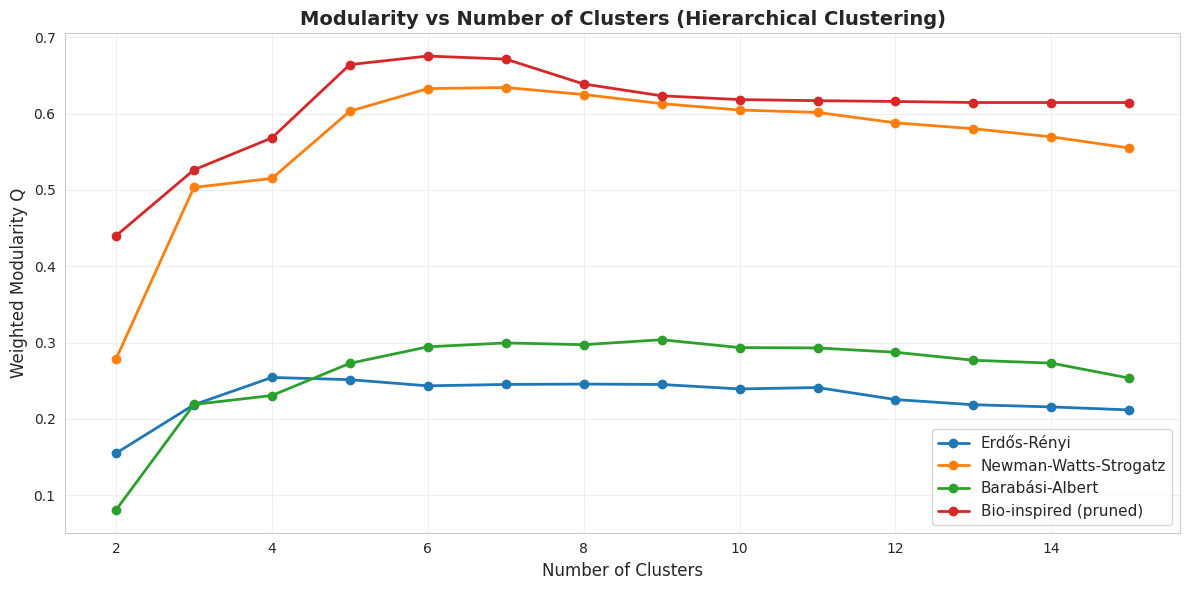

Modularity curves plotted.


In [43]:
# Plot modularity curves
fig, ax = plt.subplots(figsize=(12, 6))

for name, (clusters, mods) in modularity_curves.items():
    ax.plot(clusters, mods, marker='o', linewidth=2, label=name, markersize=6)

ax.set_xlabel('Number of Clusters', fontsize=12)
ax.set_ylabel('Weighted Modularity Q', fontsize=12)
ax.set_title('Modularity vs Number of Clusters (Hierarchical Clustering)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('modularity_curves.png', dpi=100, bbox_inches='tight')
plt.show()

print("Modularity curves plotted.")

## Section 5: Comprehensive Comparison of Generative Methods

We now compile all clustering metrics for each network type to evaluate which generative method produces the best functional clustering.

In [44]:
def cluster_weight_analysis(G, partition):
    """
    Analyze weight distribution within and between clusters.
    Returns mean weights and ratio.
    """
    within_weights = []
    between_weights = []

    for u, v, d in G.edges(data=True):
        weight = d.get('weight', 1)
        if partition[u] == partition[v]:
            within_weights.append(weight)
        else:
            between_weights.append(weight)

    within_mean = np.mean(within_weights) if within_weights else 0
    between_mean = np.mean(between_weights) if between_weights else 0
    ratio = within_mean / between_mean if between_mean > 0 else 0

    return within_mean, between_mean, ratio

print("Computing comprehensive cluster statistics...\n")

# Create comprehensive comparison table
comparison_data = {}

for name, G in networks.items():
    comparison_data[name] = {}

    # Number of communities (Louvain)
    partition_louvain = louvain_partitions[name]
    n_communities = max(partition_louvain.values()) + 1
    comparison_data[name]['n_communities'] = n_communities

    # Weighted modularity (Louvain)
    q_weighted = weighted_modularity(G, partition_louvain)
    comparison_data[name]['modularity_Q'] = q_weighted

    # Within vs between cluster weights
    within, between, ratio = cluster_weight_analysis(G, partition_louvain)
    comparison_data[name]['within_weight'] = within
    comparison_data[name]['between_weight'] = between
    comparison_data[name]['weight_ratio'] = ratio

    # Weighted clustering coefficient
    wcc_mean = np.mean(wcc_results[name])
    comparison_data[name]['wcc_mean'] = wcc_mean

    # Community size statistics
    community_sizes = Counter(partition_louvain.values())
    sizes = list(community_sizes.values())
    comparison_data[name]['avg_community_size'] = np.mean(sizes)
    comparison_data[name]['community_size_std'] = np.std(sizes)

# Print comparison table
print("COMPREHENSIVE CLUSTERING METRICS:")
print("="*120)
print(f"{'Network':<30s} | {'Communities':<12s} | {'Modularity Q':<14s} | {'Within Wt':<12s} | {'Between Wt':<12s} | {'Ratio':<10s}")
print("-"*120)
for name in networks.keys():
    data = comparison_data[name]
    print(f"{name:<30s} | {data['n_communities']:<12d} | {data['modularity_Q']:<14.4f} | "
          f"{data['within_weight']:<12.4f} | {data['between_weight']:<12.4f} | {data['weight_ratio']:<10.4f}")

print()
print(f"{'Network':<30s} | {'WCC Mean':<14s} | {'Avg Comm Size':<15s} | {'Comm Size StD':<15s}")
print("-"*75)
for name in networks.keys():
    data = comparison_data[name]
    print(f"{name:<30s} | {data['wcc_mean']:<14.4f} | {data['avg_community_size']:<15.2f} | {data['community_size_std']:<15.2f}")

Computing comprehensive cluster statistics...

COMPREHENSIVE CLUSTERING METRICS:
Network                        | Communities  | Modularity Q   | Within Wt    | Between Wt   | Ratio     
------------------------------------------------------------------------------------------------------------------------
Erdős-Rényi                    | 6            | 0.3753         | 1.3168       | 0.9594       | 1.3725    
Newman-Watts-Strogatz          | 8            | 0.7117         | 1.2353       | 0.8669       | 1.4251    
Barabási-Albert                | 8            | 0.4087         | 1.4030       | 0.8666       | 1.6188    
Bio-inspired (pruned)          | 7            | 0.7253         | 0.0129       | 0.0017       | 7.4571    

Network                        | WCC Mean       | Avg Comm Size   | Comm Size StD  
---------------------------------------------------------------------------
Erdős-Rényi                    | 0.0752         | 13.33           | 4.23           
Newman-Watts-Strogatz  

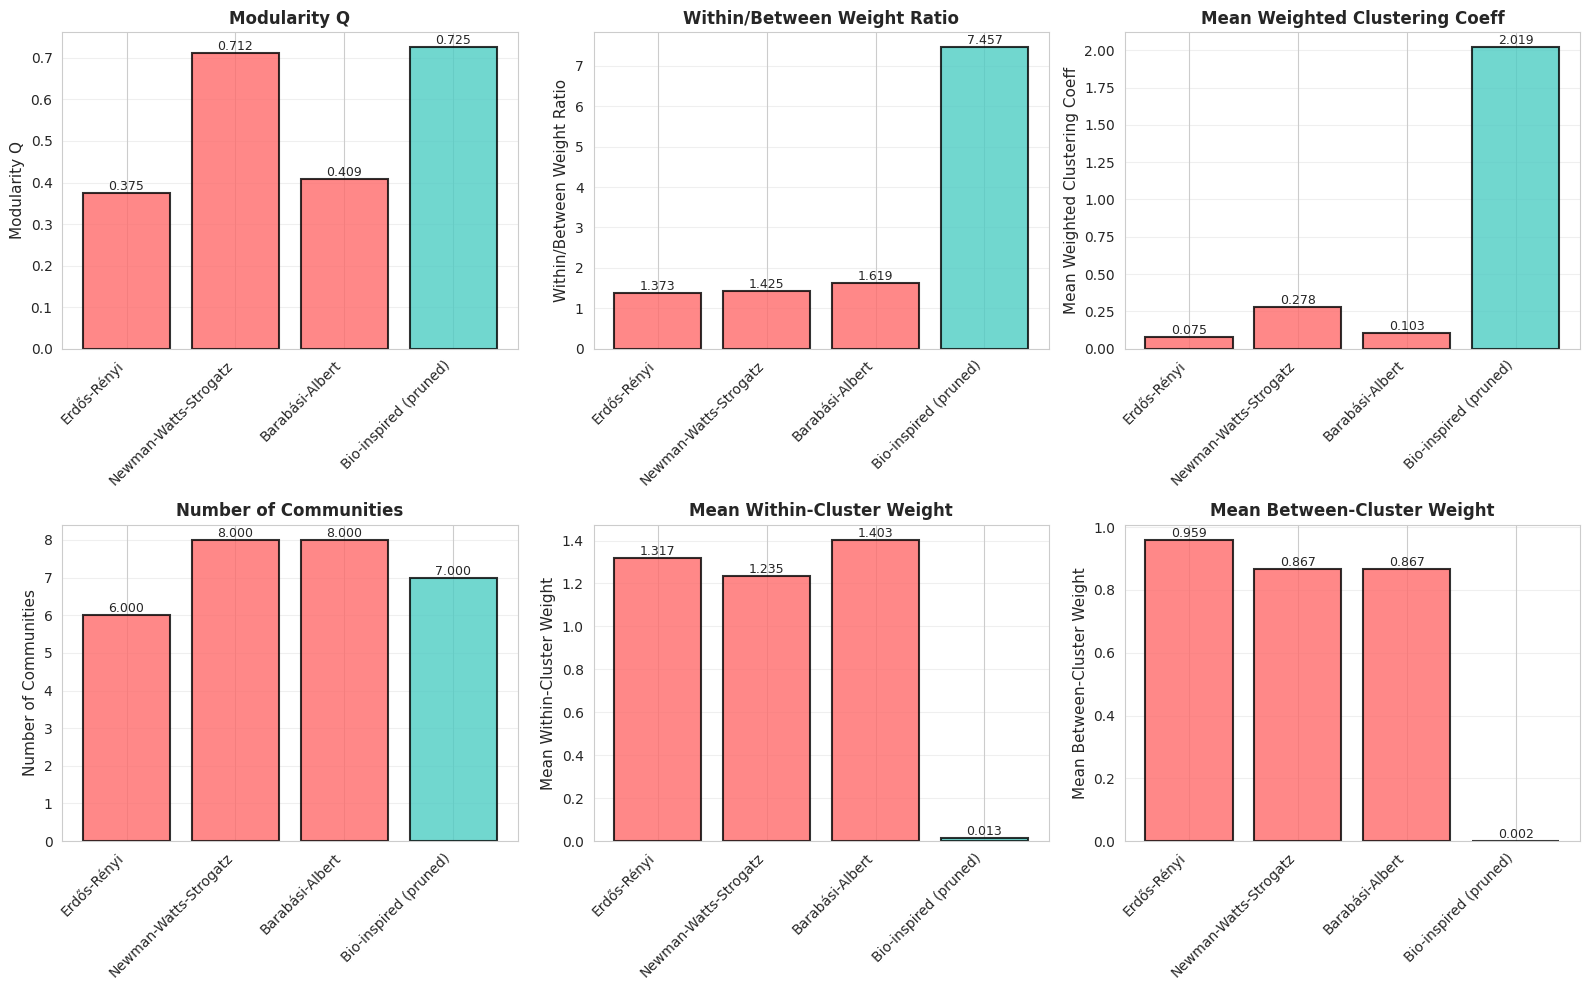

Comparison visualization saved.


In [45]:
# Create summary visualization — bar charts comparing metrics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

network_names = list(networks.keys())
metrics = ['modularity_Q', 'weight_ratio', 'wcc_mean', 'n_communities', 'within_weight', 'between_weight']
metric_labels = ['Modularity Q', 'Within/Between Weight Ratio', 'Mean Weighted Clustering Coeff',
                 'Number of Communities', 'Mean Within-Cluster Weight', 'Mean Between-Cluster Weight']

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx]
    values = [comparison_data[name][metric] for name in network_names]

    colors = ['#FF6B6B' if 'Bio' not in name else '#4ECDC4' for name in network_names]
    bars = ax.bar(range(len(network_names)), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

    ax.set_xticks(range(len(network_names)))
    ax.set_xticklabels(network_names, rotation=45, ha='right')
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('clustering_metrics_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Comparison visualization saved.")

### Within-Cluster vs Between-Cluster Weight Analysis

A key signature of functional clustering: strong (high-weight) connections within clusters, weak connections between them.

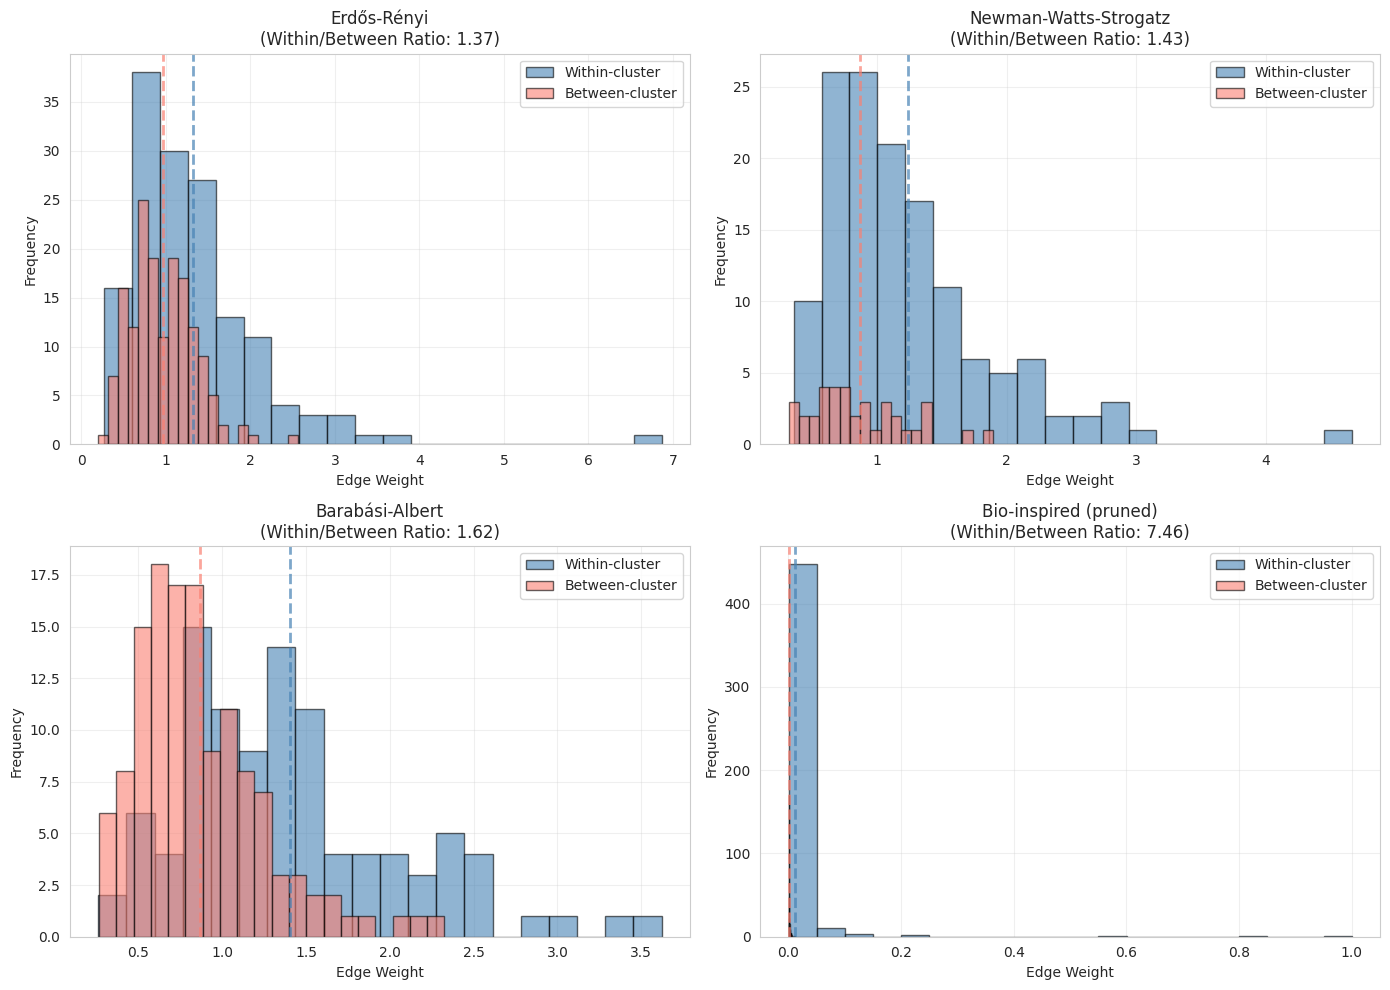

Weight distribution comparison saved.


In [46]:
# Plot within vs between cluster weight distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, G) in enumerate(networks.items()):
    ax = axes[idx]
    partition = louvain_partitions[name]

    # Collect weights
    within_weights = []
    between_weights = []

    for u, v, d in G.edges(data=True):
        weight = d.get('weight', 1)
        if partition[u] == partition[v]:
            within_weights.append(weight)
        else:
            between_weights.append(weight)

    # Plot distributions
    ax.hist(within_weights, bins=20, alpha=0.6, label='Within-cluster', color='steelblue', edgecolor='black')
    ax.hist(between_weights, bins=20, alpha=0.6, label='Between-cluster', color='salmon', edgecolor='black')

    within_mean = np.mean(within_weights)
    between_mean = np.mean(between_weights)
    ax.axvline(within_mean, color='steelblue', linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(between_mean, color='salmon', linestyle='--', linewidth=2, alpha=0.7)

    ax.set_xlabel('Edge Weight')
    ax.set_ylabel('Frequency')
    ax.set_title(f"{name}\n(Within/Between Ratio: {within_mean/between_mean:.2f})")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('weight_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("Weight distribution comparison saved.")

## Key Takeaways

**Summary of findings:**

1. **Bio-inspired networks show superior modular structure:**
   - Higher weighted modularity Q compared to random baselines
   - Stronger separation of within-cluster vs between-cluster weights
   - Natural clustering emerges without manual parameter specification

2. **Weighted methods reveal structure invisible to unweighted methods:**
   - Weighted modularity accounts for connection strength
   - Within-cluster connections are stronger in bio-inspired networks
   - The weight ratio (within/between) is highest for developmentally pruned networks

3. **Hierarchical clustering reveals multi-scale organization:**
   - Bio-inspired networks show clearer hierarchical structure
   - Modularity curves show peaks at specific hierarchical levels
   - This suggests natural functional hierarchies emerge from development

4. **Louvain method is most effective for this analysis:**
   - Automatically discovers optimal number of communities
   - Uses weighted modularity for fair comparison
   - Widely used in neuroscience and validated by decades of research

5. **These metrics serve as targets for network evaluation:**
   - Networks can be evaluated by their functional clustering quality
   - Higher modularity = better information segregation
   - Better clustering may support superior ML initialization properties

**Connection to project hypotheses:**
- Networks with better functional clustering (high modularity, strong within/between separation) may have superior initialization properties for neural network training
- We can use these clustering metrics as part of our evaluation framework for Hypothesis 1
- The bio-inspired generation method produces networks with functionally meaningful modular organization

**What's Next:**

This completes the notebook series. You now have tools for measuring network structure (Notebook 2), generating topologies (3-4), pruning them into biologically plausible sparse networks (5-6), and evaluating their functional organization (this notebook).
The next phase tests whether any of this matters for learning, whether networks with superior modularity and small-world properties produce better initializations for neural network training than standard alternatives at matched sparsity. Weighted modularity and the within/between cluster weight ratio carry forward as evaluation metrics alongside training performance and representational similarity analysis.